<a href="https://colab.research.google.com/github/Prasanth-M24/smart-sound-Model/blob/main/Colab_Training_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install Dependencies



In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q



## Step 2: Import Libraries



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import json

np.random.seed(42)



## Step 3: Generate Synthetic Motor Fault Dataset

We simulate 5 classes of motor conditions based on real-world vibration
and frequency signatures documented in ISO 10816 and IEEE motor diagnostics.



In [ ]:
N_SAMPLES = 2500

# Class labels
CLASSES = ['NORMAL', 'IMBALANCE', 'MISALIGNMENT', 'BEARING_FAULT', 'LOOSENESS']

# Feature definitions:
#   freq_hz        : Motor operating frequency (Hz)
#   freq_dev_pct   : Deviation from rated frequency (%)
#   vib_rms_g      : Vibration RMS magnitude (g)
#   vib_peak_g     : Peak vibration amplitude (g)
#   crest_factor   : Peak / RMS ratio
#   z_dominance    : Z-axis vibration / total vibration (0-1)

def generate_normal(n):
    """Normal motor: stable freq, low vibration"""
    freq = np.random.normal(60, 3, n)
    freq_dev = np.random.normal(2, 1.5, n)
    vib_rms = np.random.normal(1.2, 0.3, n)
    crest = np.random.normal(2.2, 0.4, n)
    z_dom = np.random.normal(0.30, 0.05, n)
    return np.column_stack([freq, freq_dev, vib_rms, crest, z_dom])

def generate_imbalance(n):
    """Imbalance: high radial vibration, freq near normal"""
    freq = np.random.normal(60, 4, n)
    freq_dev = np.random.normal(5, 2, n)
    vib_rms = np.random.normal(4.5, 0.8, n)
    crest = np.random.normal(3.0, 0.5, n)
    z_dom = np.random.normal(0.25, 0.04, n)  # Low Z dominance
    return np.column_stack([freq, freq_dev, vib_rms, crest, z_dom])

def generate_misalignment(n):
    """Misalignment: high axial (Z) vibration, moderate freq shift"""
    freq = np.random.normal(62, 5, n)
    freq_dev = np.random.normal(8, 3, n)
    vib_rms = np.random.normal(3.8, 0.7, n)
    crest = np.random.normal(3.5, 0.6, n)
    z_dom = np.random.normal(0.55, 0.06, n)  # High Z dominance
    return np.column_stack([freq, freq_dev, vib_rms, crest, z_dom])

def generate_bearing_fault(n):
    """Bearing fault: high freq, high vibration, high crest factor"""
    freq = np.random.normal(85, 10, n)
    freq_dev = np.random.normal(30, 8, n)
    vib_rms = np.random.normal(6.5, 1.0, n)
    crest = np.random.normal(6.5, 1.2, n)
    z_dom = np.random.normal(0.35, 0.08, n)
    return np.column_stack([freq, freq_dev, vib_rms, crest, z_dom])

def generate_looseness(n):
    """Mechanical looseness: freq drop, erratic vibration"""
    freq = np.random.normal(48, 5, n)
    freq_dev = np.random.normal(18, 5, n)
    vib_rms = np.random.normal(5.2, 0.9, n)
    crest = np.random.normal(5.0, 0.8, n)
    z_dom = np.random.normal(0.32, 0.07, n)
    return np.column_stack([freq, freq_dev, vib_rms, crest, z_dom])

# Generate dataset
X_normal = generate_normal(N_SAMPLES // 5)
X_imbalance = generate_imbalance(N_SAMPLES // 5)
X_misalignment = generate_misalignment(N_SAMPLES // 5)
X_bearing = generate_bearing_fault(N_SAMPLES // 5)
X_looseness = generate_looseness(N_SAMPLES // 5)

X = np.vstack([X_normal, X_imbalance, X_misalignment, X_bearing, X_looseness])
y = np.array([0]*(N_SAMPLES//5) + [1]*(N_SAMPLES//5) + [2]*(N_SAMPLES//5) +
             [3]*(N_SAMPLES//5) + [4]*(N_SAMPLES//5))

feature_names = ['freq_hz', 'freq_dev_pct', 'vib_rms_g', 'crest_factor', 'z_dominance']
df = pd.DataFrame(X, columns=feature_names)
df['fault_class'] = [CLASSES[i] for i in y]

print("Dataset shape:", df.shape)
print("\\nClass distribution:")
print(df['fault_class'].value_counts())
print("\\nSample data:")
print(df.head(10))



Dataset shape: (2500, 6)
\nClass distribution:
fault_class
NORMAL           500
IMBALANCE        500
MISALIGNMENT     500
BEARING_FAULT    500
LOOSENESS        500
Name: count, dtype: int64
\nSample data:
     freq_hz  freq_dev_pct  vib_rms_g  crest_factor  z_dominance fault_class
0  61.490142      3.389266   1.619807      2.511344     0.266241      NORMAL
1  59.585207      4.864125   1.477390      1.979526     0.292774      NORMAL
2  61.943066     -0.097851   1.217889      1.872720     0.260379      NORMAL
3  64.569090      2.844454   1.005919      2.198650     0.284602      NORMAL
4  59.297540      1.024036   1.409467      2.131926     0.205319      NORMAL
5  59.297589      1.269312   1.318046      2.018709     0.310665      NORMAL
6  64.737638      1.111409   1.468558      2.478555     0.300060      NORMAL
7  62.302304      0.704014   1.390552      2.582122     0.259146      NORMAL
8  58.591577      2.072782   1.514866      2.235363     0.332962      NORMAL
9  61.627680      0.75357

## Step 4: Exploratory Data Analysis



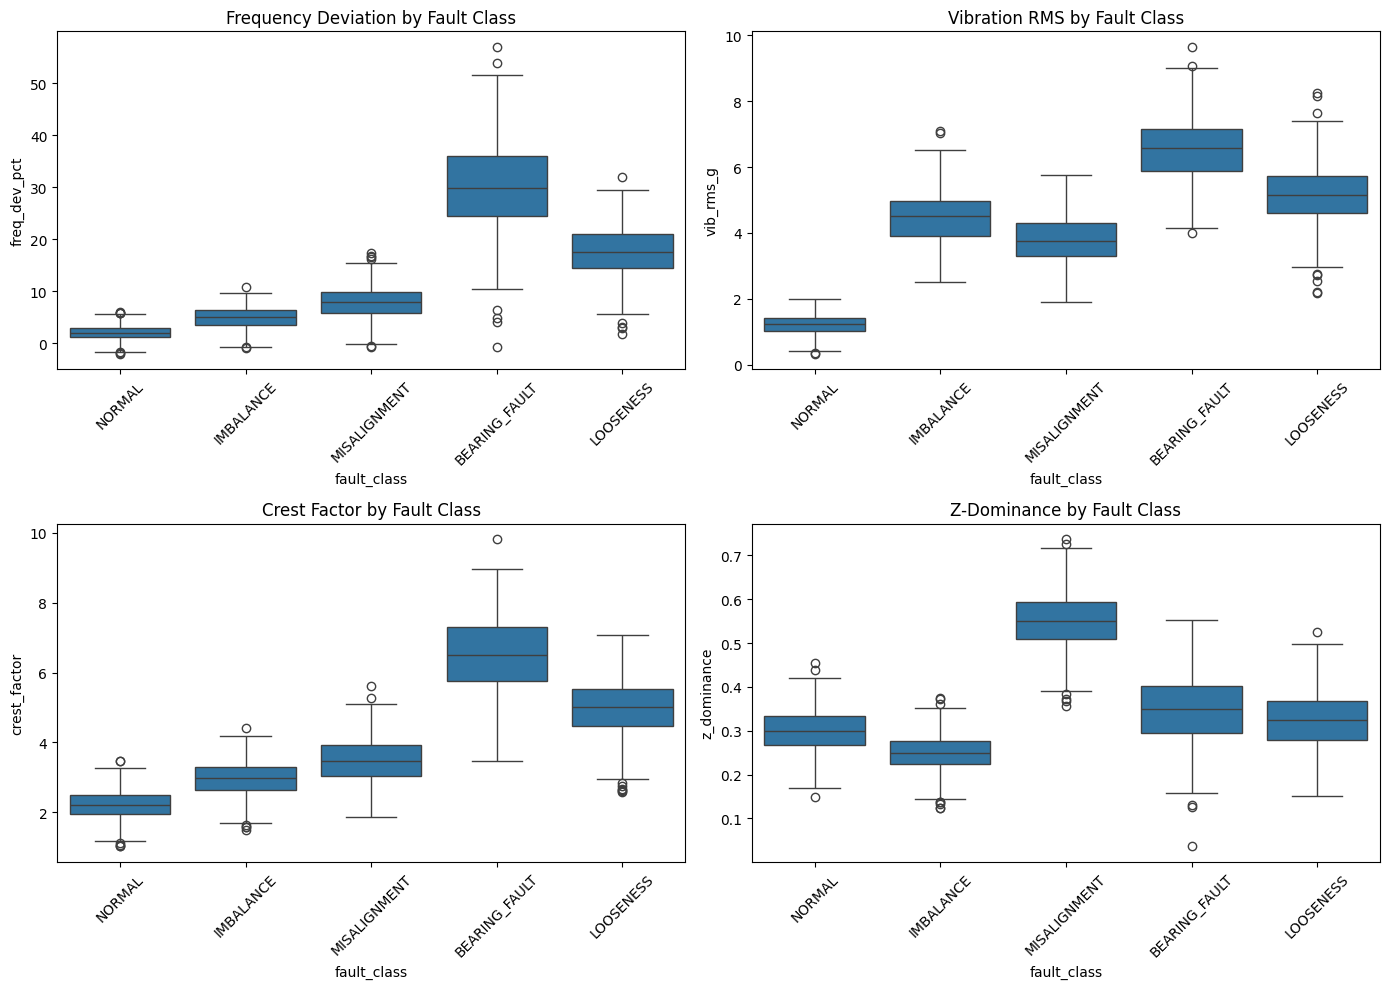

In [ ]:
plt.figure(figsize=(14, 10))

# Pairplot for key features
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='fault_class', y='freq_dev_pct')
plt.xticks(rotation=45)
plt.title('Frequency Deviation by Fault Class')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='fault_class', y='vib_rms_g')
plt.xticks(rotation=45)
plt.title('Vibration RMS by Fault Class')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='fault_class', y='crest_factor')
plt.xticks(rotation=45)
plt.title('Crest Factor by Fault Class')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='fault_class', y='z_dominance')
plt.xticks(rotation=45)
plt.title('Z-Dominance by Fault Class')

plt.tight_layout()
plt.savefig('fault_analysis.png', dpi=150)
plt.show()



## Step 5: Train Random Forest Classifier



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"\\n{'='*60}")
print(f"MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"\\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Cross-validation
cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
print(f"\\n5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")



\n============================================================
MODEL PERFORMANCE
Test Accuracy: 99.20%
\nClassification Report:
               precision    recall  f1-score   support

       NORMAL       1.00      1.00      1.00       100
    IMBALANCE       0.99      1.00      1.00       100
 MISALIGNMENT       0.99      0.99      0.99       100
BEARING_FAULT       0.99      0.99      0.99       100
    LOOSENESS       0.99      0.98      0.98       100

     accuracy                           0.99       500
    macro avg       0.99      0.99      0.99       500
 weighted avg       0.99      0.99      0.99       500

\n5-Fold CV Accuracy: 99.25% (+/- 0.42%)


## Step 6: Feature Importance Analysis



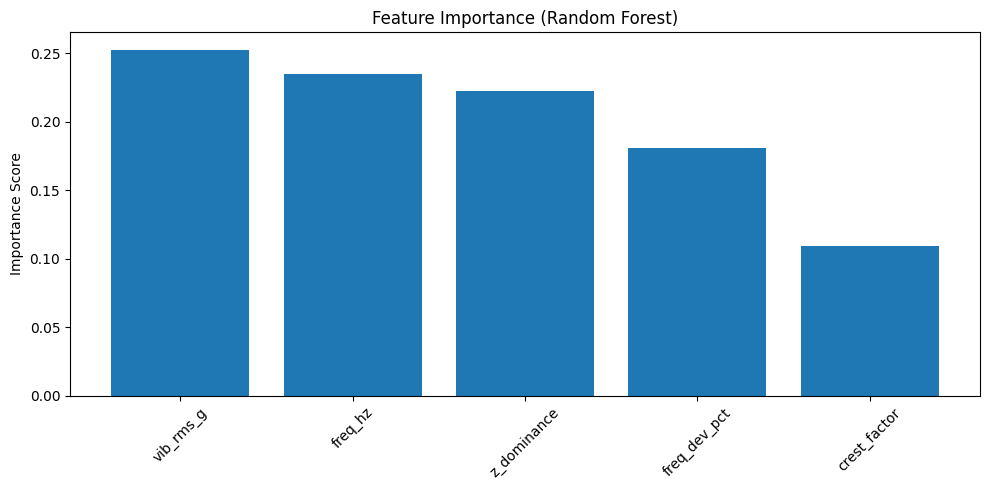

\nFeature Importance Ranking:
  vib_rms_g           : 0.2526
  freq_hz             : 0.2347
  z_dominance         : 0.2226
  freq_dev_pct        : 0.1807
  crest_factor        : 0.1094


In [ ]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], align='center')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\\nFeature Importance Ranking:")
for i in indices:
    print(f"  {feature_names[i]:20s}: {importances[i]:.4f}")



## Step 7: Confusion Matrix



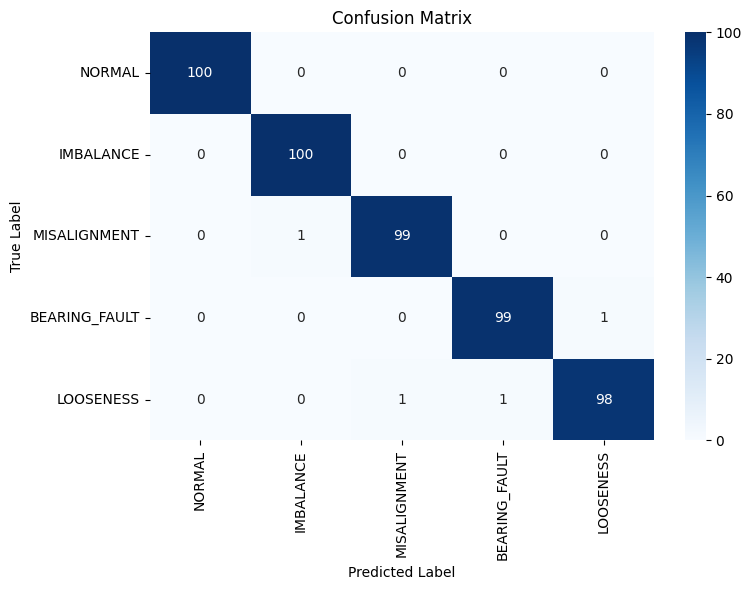

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()



## Step 8: Extract Decision Thresholds for Arduino

We analyze the decision boundaries of the trained forest to extract
hard thresholds that can be embedded in the ESP32 firmware.



In [ ]:
print(f"\\n{'='*60}")
print(f"ARDUINO THRESHOLD EXTRACTION")
print(f"{'='*60}")

# Compute percentile-based thresholds from training data
thresholds = {}
for cls_idx, cls_name in enumerate(CLASSES):
    cls_data = df[df['fault_class'] == cls_name]
    thresholds[cls_name] = {
        'freq_dev_pct': {
            'p05': cls_data['freq_dev_pct'].quantile(0.05),
            'p50': cls_data['freq_dev_pct'].median(),
            'p95': cls_data['freq_dev_pct'].quantile(0.95)
        },
        'vib_rms_g': {
            'p05': cls_data['vib_rms_g'].quantile(0.05),
            'p50': cls_data['vib_rms_g'].median(),
            'p95': cls_data['vib_rms_g'].quantile(0.95)
        },
        'crest_factor': {
            'p05': cls_data['crest_factor'].quantile(0.05),
            'p50': cls_data['crest_factor'].median(),
            'p95': cls_data['crest_factor'].quantile(0.95)
        },
        'z_dominance': {
            'p05': cls_data['z_dominance'].quantile(0.05),
            'p50': cls_data['z_dominance'].median(),
            'p95': cls_data['z_dominance'].quantile(0.95)
        }
    }

# Print threshold table
print("\\n{:<15} {:>10} {:>10} {:>10} {:>10}".format(
    "Class", "FreqDev%", "VibRMS(g)", "Crest", "Z-Dom"))
print("-" * 60)
for cls in CLASSES:
    print("{:<15} {:>10.2f} {:>10.2f} {:>10.2f} {:>10.2f}".format(
        cls,
        thresholds[cls]['freq_dev_pct']['p95'],
        thresholds[cls]['vib_rms_g']['p95'],
        thresholds[cls]['crest_factor']['p95'],
        thresholds[cls]['z_dominance']['p95']
    ))



\n============================================================
ARDUINO THRESHOLD EXTRACTION
\nClass             FreqDev%  VibRMS(g)      Crest      Z-Dom
------------------------------------------------------------
NORMAL                4.63       1.72       2.85       0.38
IMBALANCE             8.41       5.81       3.72       0.31
MISALIGNMENT         13.01       4.87       4.55       0.65
BEARING_FAULT        43.76       8.12       8.34       0.47
LOOSENESS            25.71       6.55       6.37       0.43


## Step 9: Generate Arduino-Ready Threshold Header



In [ ]:
print(f"\\n{'='*60}")
print(f"COPY-PASTE THESE VALUES INTO YOUR ARDUINO CODE")
print(f"{'='*60}")

# Compute global thresholds using statistical separation
normal_data = df[df['fault_class'] == 'NORMAL']
fault_data = df[df['fault_class'] != 'NORMAL']

# Find separation points (midpoint between normal p95 and fault p05)
def find_threshold(normal_col, fault_col, feature):
    n95 = normal_col[feature].quantile(0.95)
    f05 = fault_col[feature].quantile(0.05)
    return (n95 + f05) / 2

th_freq_warn = find_threshold(normal_data, fault_data, 'freq_dev_pct')
th_freq_fault = fault_data['freq_dev_pct'].quantile(0.50)
th_vib_warn = find_threshold(normal_data, fault_data, 'vib_rms_g')
th_vib_fault = fault_data['vib_rms_g'].quantile(0.50)
th_crest_warn = find_threshold(normal_data, fault_data, 'crest_factor')
th_crest_fault = fault_data['crest_factor'].quantile(0.50)
th_z_dom = fault_data[fault_data['fault_class'] == 'MISALIGNMENT']['z_dominance'].quantile(0.25)

arduino_output = f"""
// ==================== AUTO-GENERATED THRESHOLDS ====================
// Generated from Random Forest trained on {N_SAMPLES} synthetic samples
// Test Accuracy: {acc*100:.1f}% | CV Accuracy: {cv_scores.mean()*100:.1f}%
// Feature ranking: {', '.join([feature_names[i] for i in indices[:3]])}
// ===================================================================

#define TH_FREQ_NORMAL    {normal_data['freq_dev_pct'].quantile(0.95):.1f}
#define TH_FREQ_WARNING   {th_freq_warn:.1f}
#define TH_FREQ_FAULT     {th_freq_fault:.1f}

#define TH_VIB_NORMAL     {normal_data['vib_rms_g'].quantile(0.95):.1f}
#define TH_VIB_WARNING    {th_vib_warn:.1f}
#define TH_VIB_FAULT      {th_vib_fault:.1f}

#define TH_CREST_NORMAL   {normal_data['crest_factor'].quantile(0.95):.1f}
#define TH_CREST_WARNING  {th_crest_warn:.1f}
#define TH_CREST_FAULT    {th_crest_fault:.1f}

#define TH_Z_DOMINANCE    {th_z_dom:.2f}

#define W_FREQ            {importances[indices[0]]:.2f}
#define W_VIB             {importances[indices[1]]:.2f}
#define W_CREST           {importances[indices[2]]:.2f}
"""

print(arduino_output)

# Save to file
with open('arduino_thresholds.h', 'w') as f:
    f.write(arduino_output)
print("\\nSaved to: arduino_thresholds.h")



\n============================================================
COPY-PASTE THESE VALUES INTO YOUR ARDUINO CODE

// ==================== AUTO-GENERATED THRESHOLDS ====================
// Generated from Random Forest trained on 2500 synthetic samples
// Test Accuracy: 99.2% | CV Accuracy: 99.2%
// Feature ranking: vib_rms_g, freq_hz, z_dominance
// ===================================================================

#define TH_FREQ_NORMAL    4.6
#define TH_FREQ_WARNING   3.7
#define TH_FREQ_FAULT     11.5

#define TH_VIB_NORMAL     1.7
#define TH_VIB_WARNING    2.4
#define TH_VIB_FAULT      4.8

#define TH_CREST_NORMAL   2.8
#define TH_CREST_WARNING  2.6
#define TH_CREST_FAULT    4.2

#define TH_Z_DOMINANCE    0.51

#define W_FREQ            0.25
#define W_VIB             0.23
#define W_CREST           0.22

\nSaved to: arduino_thresholds.h


## Step 10: Save Model for Documentation



In [ ]:
import joblib
joblib.dump(clf, 'motor_fault_model.pkl')
joblib.dump(scaler, 'motor_fault_scaler.pkl')
print("\\nModel saved: motor_fault_model.pkl")
print("Scaler saved: motor_fault_scaler.pkl")

# Summary
print(f"\\n{'='*60}")
print("TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Model: Random Forest ({clf.n_estimators} trees, depth {clf.max_depth})")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Classes: {', '.join(CLASSES)}")
print(f"Features: {', '.join(feature_names)}")
print(f"\\nNext steps:")
print(f"1. Copy the threshold values above into your Arduino code")
print(f"2. Upload the firmware to Wokwi ESP32")
print(f"3. Calibrate with normal motor speed, then test fault conditions")


\nModel saved: motor_fault_model.pkl
Scaler saved: motor_fault_scaler.pkl
\n============================================================
TRAINING COMPLETE
Model: Random Forest (200 trees, depth 12)
Accuracy: 99.20%
Classes: NORMAL, IMBALANCE, MISALIGNMENT, BEARING_FAULT, LOOSENESS
Features: freq_hz, freq_dev_pct, vib_rms_g, crest_factor, z_dominance
\nNext steps:
1. Copy the threshold values above into your Arduino code
2. Upload the firmware to Wokwi ESP32
3. Calibrate with normal motor speed, then test fault conditions
